# **Εργασία 3**

**Καθηγητής:**  Θεοδωρακόπουλος Ηλίας

**Φοιτητής:** Ιατρού Κωνσταντίνος 58071

# Άσκηση 4

Κατεβάστε από εδώ το dataset «Air Distances Between Cities in Statute Miles» που περιέχει την απόσταση μεταξύ πόλεων είτε του κόσμου είτε των Ηνωμένων πολιτειών μετρούμενων σε μίλια κατά μήκος μέγιστων κύκλων.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

Σε πρώτη φάση, όπως πάντα, εισάγω τις βιβλιοθήκες που θα χρειαστούν στην συνέχεια της άσκησης.


1.  Η numpy που χρησιμοποιήθηκε και στις προηγούμενες εργασίες, καθώς διευκολύνει πράξεις με πίνακες και διανύσματα λόγω της δομής ndarray που ορίζεται μέσω αυτής.
2.  Το module pyplot της matplotlib το οποίο χρησιμοποιείται για την τύπωση διαγραμμάτων.
3.  Η κλάση MDS. Η οποία περιέχει συναρτήσεις για την εφαρμογή της μεθόδου MDS για την μείωση των διαστάσεων ενός προβλήματος και συχνά βοηθά στην οπτικοποίηση της δομής των δεδομένων υψηλών διαστάσεων.

# Ερώτημα Α

Α.	Χρησιμοποιείστε τη μέθοδο classical MDS για να δημιουργήσετε μία διανυσματική αναπαράσταση των πόλεων του κόσμου (Distance_Matrix_world) στις δύο και στις τρεις διαστάσεις. Απεικονίστε τις αναπαραστάσεις αυτές σε κατάλληλο διάγραμμα και σχολιάστε το αποτέλεσμα.

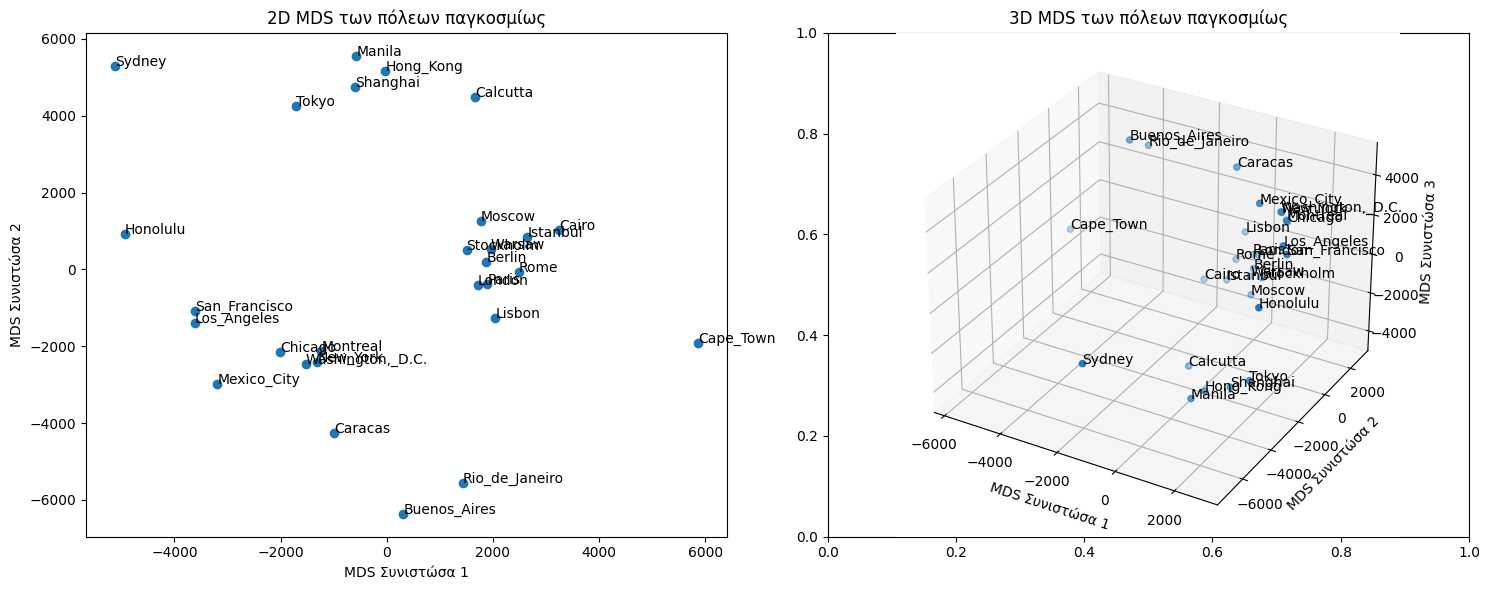

In [2]:
distance_matrix = np.loadtxt('Distance_Matrix_world.txt', encoding=None)
city_names = np.loadtxt('City_names_world.txt', dtype='str', encoding=None)

# 2D MDS
mds_2d = MDS(n_components=2, normalized_stress='auto', dissimilarity="precomputed", random_state=123)
coords_2d = mds_2d.fit_transform(distance_matrix)

# 3D MDS
mds_3d = MDS(n_components=3, normalized_stress='auto', dissimilarity="precomputed", random_state=123)
coords_3d = mds_3d.fit_transform(distance_matrix)

# Figure με 2 απεικονίσεις
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 2D Plot
ax[0].scatter(coords_2d[:, 0], coords_2d[:, 1])
for i, txt in enumerate(city_names):
    ax[0].annotate(txt, (coords_2d[i, 0], coords_2d[i, 1]))
ax[0].set_title('2D MDS των πόλεων παγκοσμίως')
ax[0].set_xlabel('MDS Συνιστώσα 1')
ax[0].set_ylabel('MDS Συνιστώσα 2')

# 3D Plot
ax_3d = fig.add_subplot(1, 2, 2, projection='3d')
ax_3d.scatter(coords_3d[:, 0], coords_3d[:, 1], coords_3d[:, 2])
for i, txt in enumerate(city_names):
    ax_3d.text(coords_3d[i, 0], coords_3d[i, 1], coords_3d[i, 2], txt)
ax_3d.set_title('3D MDS των πόλεων παγκοσμίως')
ax_3d.set_xlabel('MDS Συνιστώσα 1')
ax_3d.set_ylabel('MDS Συνιστώσα 2')
ax_3d.set_zlabel('MDS Συνιστώσα 3')

plt.tight_layout()
plt.show()

Αρχικά φορτώνων τα δεδομένα. Στην μεταβλητή distance_matrix θα φορτωθούν οι αποστάσεις μεταξύ όλων των πόλεων σε μορφή πίνακα και στην μεταβλητή city_names θα φορτωθούν τα ονόματα όλων των πόλεων με την σειρά που εμφανίζονται στον πίνακα που περιέχει τις αποστάσεις.

Στην συνέχεια, με χρήση της κλάσης MDS εφαρμόζουμε την μέθοδο μείωσης διαστάσεων πάνω στα δεδομένα πρώτα για 2 διαστάσεις και αργότερα για 3 και μεταφέρουμε τα δεδομένα στους νέους χώρους δύο και τριών διαστάσεων αντίστοιχα. Η αρχικές διαστάσεις του προβλήματος ήταν όσες και οι πόλεις (28) καθώς είχαμε έναν πίνακα που εδίνε την απόσταση κάθε πόλης από όλες τις υπόλοιπες.

Κατά την εφαρμογή της MDS στις παραμέτρους εισόδου δίνεται η παράμετρος dissimilarity='precomputed'. Επιλέγεται η precomputed έναντι της euclidean γιατί δίνουμε τις αποστάσεις μεταξύ όλων των πόλεων έτοιμες σε έναν πίνακα. Η παράμετρος euclidean επιλέγεται όταν θέλουμε η MDS να υπολογίσει και τις αποστάσεις αν εμείς έχουμε απλά τα διανύσματα της θέσεις των δεδομένων (εδώ πόλεις).

Στην συνέχεια δημιουργεί τις δύο απεικονίσεις, τα δεδομένα στις απεικονίσεις εισάγονται ένα-ένα με την βοήθεια μίας επαναληπτικής διαδικασίας για κάθε απεικόνιση, έτσι ώστε πέρα από την πόλη ώς σημείο στην απεικόνιση να εμφανίζεται και το όνομα της από δίπλα για να βλέπουμε κάθε σημείο ποιο δεδομένο αναπαριστά. (Εξού και η επιλογή της enumerate, ώστε να απαριθμούνται οι πόλεις, αλλά να κρατάμε και το όνομα τους)

 Προσθέτων τίτλο σε κάθε διάγραμμα και ονόματα σε κάθε άξονα και εμφανίζω τα σχήματα.

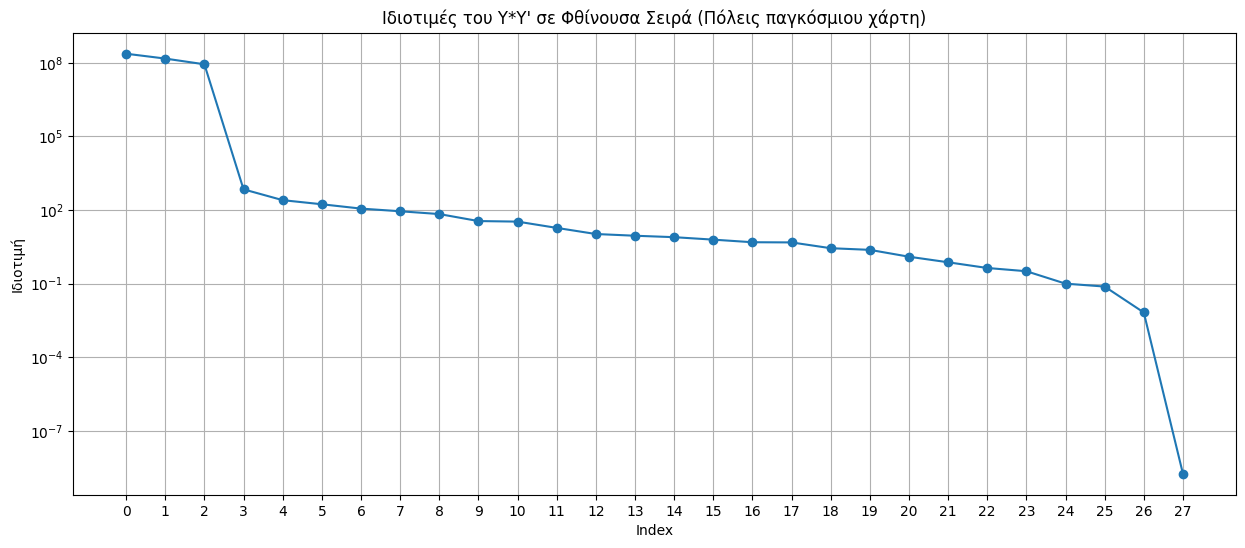


 Οι ταξινομημένες, κατά φθίνουσα σειρά ταξινόμησης, τιμές των ιδιοτιμών είναι οι παρακάτω:
 [2.35339830e+08 1.49210115e+08 8.72224624e+07 6.94791873e+02
 2.51634815e+02 1.71102338e+02 1.13992798e+02 8.87222399e+01
 6.82632912e+01 3.53747189e+01 3.35776711e+01 1.86337599e+01
 1.04849204e+01 8.91986523e+00 7.79238103e+00 6.18147046e+00
 4.84464516e+00 4.76378118e+00 2.76563699e+00 2.36898814e+00
 1.24437308e+00 7.37701951e-01 4.31855960e-01 3.18658989e-01
 9.92424145e-02 7.54948204e-02 6.61819448e-03 1.76348901e-09]

Ο καλύτερος αριθμός διαστάσεων που πρέπει να κρατήσουμε είναι: 3


In [3]:
# Ο μέγιστος αριθμός συνιστωσών που μπορούμε να εφαρμόσουμε την MDS είναι όσες και οι πόλεις
max_dims = len(city_names)

# Εφαρμογή MDS για τις μέγιστες δυνατές συνιστώσες (διαστάσεις)
mds_max_dims = MDS(n_components=max_dims, normalized_stress='auto', dissimilarity="precomputed", random_state=0)
coords_max_dims = mds_max_dims.fit_transform(distance_matrix)

# Υπολογισμός Y*Y_αναστροφος
Y = coords_max_dims
Y_Yt = Y.dot(Y.T)

# Υπολογισμός ιδιοτιμών
eigenvalues, _ = np.linalg.eig(Y_Yt)

# Ταξινόμηση ιδιοτιμών σε φθίνουσα σειρά
sorted_eigenvalues = np.sort(eigenvalues)[::-1]

# Δημιουργία διαγράμματος των ιδιοτιμών για κάθε συνιστώσα αφου ταξινομήθηκαν σε φθίνουσα σείρα
plt.figure(figsize=(15, 6))
plt.semilogy(sorted_eigenvalues, 'o-')
plt.title('Ιδιοτιμές του Y*Y\' σε Φθίνουσα Σειρά (Πόλεις παγκόσμιου χάρτη)')
plt.xlabel('Index')
plt.ylabel('Ιδιοτιμή')
plt.xticks(range(0,28))
plt.grid(True)
plt.show()

print("\n Οι ταξινομημένες, κατά φθίνουσα σειρά ταξινόμησης, τιμές των ιδιοτιμών είναι οι παρακάτω:\n", sorted_eigenvalues)

optimal_dims = len(np.where(sorted_eigenvalues>=0.1*sorted_eigenvalues[0])[0])
print("\nΟ καλύτερος αριθμός διαστάσεων που πρέπει να κρατήσουμε είναι:", optimal_dims)

Αρχικά ορίζω τον μέγιστο αριθμό διαστάσεων ο οποίος είναι ίσος με τον αριθμό των πόλεων.

Στην συνέχεια εκτελούμε την μέθοδο MDS στον πίνακα με τις αποστάσεις για τόν μέγιστο δυνατό αριθμό διαστάσεων, χρησιμοποιώντας την παράμετρο precomputed, αφού εισάγω τα δεδομένα ήδη σε μορφή πίνακα αποστάσεων. Αφου εφαρμόσω την MDS μεταφέρω και τα δεδομένα στον νέο χώρο των 28 διαστάσεων.

Στην συνέχεια υπολογίζω των πίνακα Y*Y', ο οποίος περιέχει σημαντικές πληροφορίες για την δομή των δεδομένων στον χώρο. Αμέσως μετά υπολογίζω τις ιδιοτιμές αυτού του πίνακα με την εντολή:

eigenvalues, _ = np.linalg.eig(Y_Yt)

Η συνάρτηση επιστρέφει κανονικά τις ιδιοτιμές και τα ιδιοδιανύσματα, αλλά με την κάτω παύλα ορίζω ότι δεν με ενδιαφέρει να αποθηκεύσω κάπου τα ιδιοδιανύσματα και κρατάω μόνο τις ιδιοτιμές μέσα στην μεταβλητή eigenvalues.

Ταξινομώ τις ιδιοτιμές με φθίνουσα σειρά και στην συνέχεια απεικονίζονται σε διάγραμμα του οποίου ο οριζόντιος άξονας είναι γραμμικός και ο κατακόρυφος επιλέχθηκε να είναι λογαριθμικός γιατί το εύρος των τάξεων μεγέθους των ιδιοτιμών είναι αρκετά μεγάλο (από 10^8 έως και 10^(-9)).

Για να υπολογίσουμε τον βέλτιστο αριθμό διαστάσεων θεώρησα ότι καλό είναι να επιλεγούν όσες διαστάσεις των οποίων οι τάξη μεγέθους της ιδιοτιμής τους ανήκοι έως και το πολύ μία τάξη μεγέθους χαμηλότερα από την ιδιοτιμή της πρώτης διάστασης.

Εν τέλει επιλέγονται 3 διαστάσεις γιατί η τέταρτη διάστασης δεν έχει απλά ιδιοτιμή πάνω από μία τάξη μικρότερη από την ιδιοτιμή της πρώτης, αλλά έχει 5 τάξεις μεγέθους μικρότερη τιμή, το οποίο φαίνεται αφού τυπώνω τις ταξινομημένες ιδιοτιμές μετά το διάγραμμα.

# Bonus

Για ποιο λόγο υπάρχουν μη μηδενικές ιδιοτιμές για περισσότερες των 3
διαστάσεων στο παραπάνω πρόβλημα; Συγκρίνετε το αντίστοιχο διάγραμμα για τα
δεδομένα του αρχείου Distance_Matrix_US. Που οφείλεται αυτή η διαφορά και πως
σχετίζεται με τη φύση του προβλήματος και των δεδομένων;

(Εδώ θα υλοποίηθεί μόνο το διάγραμμα του αρχείου Distance_Matrix_US. Η απάντηση των θεωρητικών ερωτημάτων γίνεται στην αναφορά)

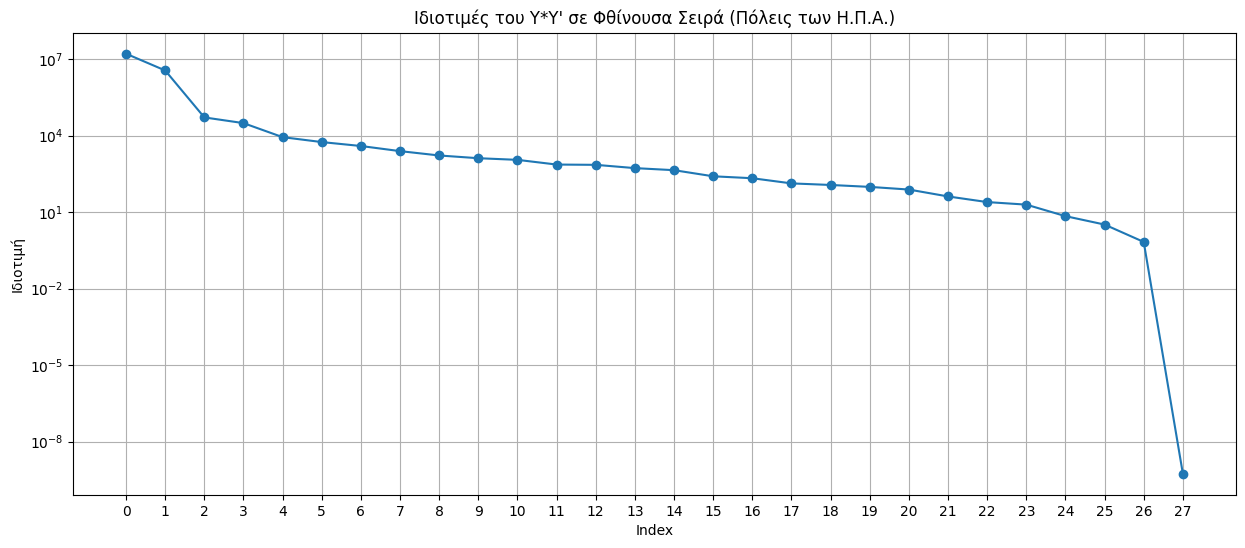


 Οι ταξινομημένες, κατά φθίνουσα σειρά ταξινόμησης, τιμές των ιδιοτιμών είναι οι παρακάτω:
 [1.62421820e+07 3.58043209e+06 5.16079137e+04 3.08387105e+04
 8.68702331e+03 5.56790993e+03 3.90360461e+03 2.45676595e+03
 1.65835495e+03 1.29625091e+03 1.11782235e+03 7.30985901e+02
 7.12458361e+02 5.29919806e+02 4.39932641e+02 2.53265747e+02
 2.12654929e+02 1.33433319e+02 1.15698816e+02 9.72697310e+01
 7.65184230e+01 4.10461884e+01 2.46947740e+01 1.95908416e+01
 6.92859558e+00 3.23984924e+00 6.74380191e-01 5.47904576e-10]

Ο καλύτερος αριθμός διαστάσεων που πρέπει να κρατήσουμε είναι: 2


In [6]:
distance_matrix_us = np.loadtxt('Distance_Matrix_US.txt', encoding=None)
city_names_us = np.loadtxt('City_names_US.txt', dtype='str', encoding=None)

# Ο μέγιστος αριθμός συνιστωσών που μπορούμε να εφαρμόσουμε την MDS είναι όσες και οι πόλεις
max_dims_us = len(city_names_us)

# Εφαρμογή MDS για τις μέγιστες δυνατές συνιστώσες (διαστάσεις)
mds_max_dims_us = MDS(n_components=max_dims_us, normalized_stress='auto', dissimilarity="precomputed", random_state=0)
Y_us = mds_max_dims.fit_transform(distance_matrix_us)

# Υπολογισμός Y*Y_αναστροφος
Y_Yt_us = Y_us.dot(Y_us.T)

# Υπολογισμός ιδιοτιμών
eigenvalues_us, _ = np.linalg.eig(Y_Yt_us)

# Ταξινόμηση ιδιοτιμών σε φθίνουσα σειρά
sorted_eigenvalues_us = np.sort(eigenvalues_us)[::-1]

# Δημιουργία διαγράμματος των ιδιοτιμών για κάθε συνιστώσα αφου ταξινομήθηκαν σε φθίνουσα σείρα
plt.figure(figsize=(15, 6))
plt.semilogy(sorted_eigenvalues_us, 'o-')
plt.title('Ιδιοτιμές του Y*Y\' σε Φθίνουσα Σειρά (Πόλεις των Η.Π.Α.)')
plt.xlabel('Index')
plt.ylabel('Ιδιοτιμή')
plt.xticks(range(0,28))
plt.grid(True)
plt.show()

print("\n Οι ταξινομημένες, κατά φθίνουσα σειρά ταξινόμησης, τιμές των ιδιοτιμών είναι οι παρακάτω:\n", sorted_eigenvalues_us)

optimal_dims_us = len(np.where(sorted_eigenvalues_us>=0.1*sorted_eigenvalues_us[0])[0])
print("\nΟ καλύτερος αριθμός διαστάσεων που πρέπει να κρατήσουμε είναι:", optimal_dims_us)

Εδώ η υλοποίηση δεν έχει κάτι να σχολιάσουμε από αποψη κώδικα, καθώς είναι ολόιδια με αυτή του προηγούμενου ερωτήματος, αλλά για τις πόλεις της Αμερικής.